# Milestone 1: Chicago Crime Data Visualization (2024 - Present)
**Date:** April 3, 2026  
**Dataset:** Chicago Police Department Incident Records

### Project Goal
This project aims to visualize crime patterns in Chicago to identify temporal trends (when crimes happen) and spatial hotspots (where they happen). The target audience includes urban planners and public safety researchers.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define dtypes to save memory during load
# 'category' is much lighter than 'object/string'
dtype_dict = {
    'Primary Type': 'category',
    'Location Description': 'category',
    'Arrest': 'bool',
    'Domestic': 'bool',
    'District': 'float32',
    'Community Area': 'float32'
}

# Use usecols to only load what you NEED for the Milestone to save RAM
df = pd.read_csv('chicago_crimes.csv', dtype=dtype_dict)

# Optimization: Convert Date now to free up the string-version from memory
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y %I:%M:%S %p')

print(f"Memory usage : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

/tmp/ipykernel_27142/1097690236.py:18: DtypeWarning: Columns (0: IUCR) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('chicago_crimes.csv', dtype=dtype_dict)


Memory usage : 4722.75 MB


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8500901 entries, 0 to 8500900
Data columns (total 22 columns):
 #   Column                Dtype         
---  ------                -----         
 0   ID                    int64         
 1   Case Number           str           
 2   Date                  datetime64[us]
 3   Block                 str           
 4   IUCR                  object        
 5   Primary Type          category      
 6   Description           str           
 7   Location Description  category      
 8   Arrest                bool          
 9   Domestic              bool          
 10  Beat                  int64         
 11  District              float32       
 12  Ward                  float64       
 13  Community Area        float32       
 14  FBI Code              str           
 15  X Coordinate          float64       
 16  Y Coordinate          float64       
 17  Year                  int64         
 18  Updated On            str           
 19  Latitude   

## 1. Dataset Quality & Preprocessing
In this section, we assess the "cleanliness" of the data. Key areas of concern are missing geographical coordinates and ensuring the `date` column is in a machine-readable format.

In [3]:
# Check for missing values
print("Missing Values Analysis:")
display(df.isnull().sum())

Missing Values Analysis:


ID                           0
Case Number                  0
Date                         0
Block                        0
IUCR                         0
Primary Type                 0
Description                  0
Location Description     15626
Arrest                       0
Domestic                     0
Beat                         0
District                    47
Ward                    614818
Community Area          613685
FBI Code                     0
X Coordinate             94671
Y Coordinate             94671
Year                         0
Updated On                   0
Latitude                 94671
Longitude                94671
Location                 94671
dtype: int64

## 2. Exploratory Data Analysis (EDA)
Here we look at the basic distribution of crimes. We want to understand which crimes are most prevalent and how often the police successfully make an arrest.

### 1. Temporal Range and Volume
Before diving into specifics, we need to understand the "time horizon" of our dataset. This section identifies the earliest and latest recorded incidents and examines how the volume of crime reports has evolved annually from 2001 to the present.

Dataset start date: 2001-01-01
Dataset end date:   2026-02-16


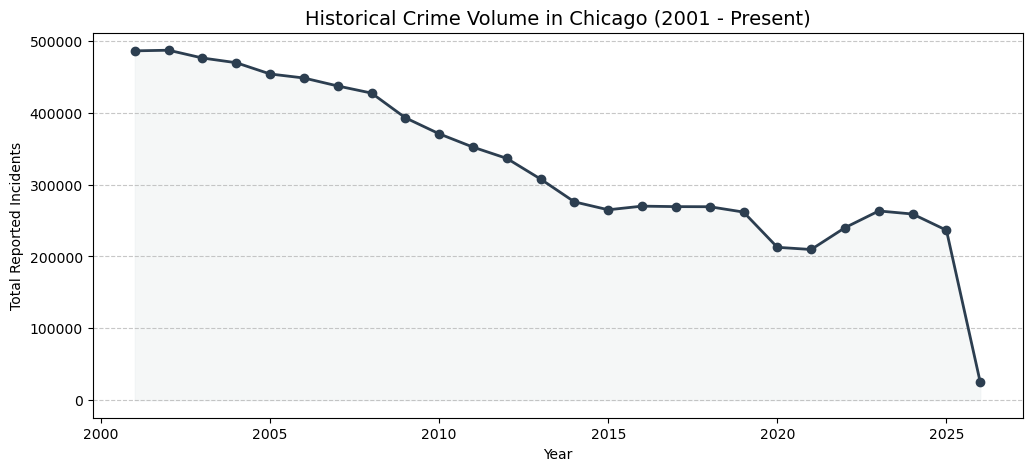

In [4]:
# Calculate temporal boundaries
date_min = df['Date'].min()
date_max = df['Date'].max()

print(f"Dataset start date: {date_min.strftime('%Y-%m-%d')}")
print(f"Dataset end date:   {date_max.strftime('%Y-%m-%d')}")

# Aggregate by Year
yearly_counts = df['Year'].value_counts().sort_index()

# Plotting the historical trend
plt.figure(figsize=(12, 5))
yearly_counts.plot(kind='line', marker='o', color='#2c3e50', linewidth=2)
plt.fill_between(yearly_counts.index, yearly_counts.values, color='#ecf0f1', alpha=0.5)
plt.title('Historical Crime Volume in Chicago (2001 - Present)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Total Reported Incidents')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 2. Spatial Scope and Location Variety
In this section, we identify the diversity of environments where crimes are reported. We calculate the total number of unique location types and examine the geographical boundaries (Latitude/Longitude) to ensure the data is contained within the Chicago city limits.

In [10]:
# 1. Location Descriptions
unique_locs = df['Location Description'].unique()
print(f"Total Unique Location Types: {len(unique_locs)}")
print(f"Sample Locations: {list(unique_locs[:10])}")

# 2. Geographical Boundaries
lat_range = (df['Latitude'].min(), df['Latitude'].max())
lon_range = (df['Longitude'].min(), df['Longitude'].max())

print(f"\nGeographical Range:")
print(f"Latitude:  {lat_range[0]} to {lat_range[1]}")
print(f"Longitude: {lon_range[0]} to {lon_range[1]}")

# 3. Top 5 most frequent locations
print("\nTop 5 Location Environments:")
print(df['Location Description'].value_counts().head(5))

Total Unique Location Types: 219
Sample Locations: ['RESIDENCE', 'SIDEWALK', 'STREET', 'HOTEL/MOTEL', 'PARKING LOT / GARAGE (NON RESIDENTIAL)', 'BANK', 'OTHER (SPECIFY)', 'RESIDENCE - PORCH / HALLWAY', 'RESIDENCE - GARAGE', 'CTA PLATFORM']

Geographical Range:
Latitude:  36.619446395 to 42.022910333
Longitude: -91.686565684 to -87.524529378

Top 5 Location Environments:
Location Description
STREET       2221334
RESIDENCE    1392463
APARTMENT    1017103
SIDEWALK      765719
OTHER         269924
Name: count, dtype: int64


### 3. Administrative and Police Jurisdictions
The dataset is organized into various city divisions. We check the range of Wards, Districts, and Community Areas. This is crucial for our visualization to determine which "zoom level" (District vs. Ward) provides the most consistent data for mapping.

In [12]:
# Check ranges for administrative columns
admin_summary = pd.DataFrame({
    'Min Value': [df['District'].min(), df['Ward'].min(), df['Community Area'].min()],
    'Max Value': [df['District'].max(), df['Ward'].max(), df['Community Area'].max()],
    'Unique Count': [df['District'].nunique(), df['Ward'].nunique(), df['Community Area'].nunique()]
}, index=['District', 'Ward', 'Community Area'])

display(admin_summary)

print(f"Note: There are {df['Beat'].nunique()} unique Police Beats across the city.")

,Min Value,Max Value,Unique Count
District,1.0,31.0,24
Ward,1.0,50.0,50
Community Area,0.0,77.0,78


Note: There are 305 unique Police Beats across the city.


### 4. Classification Breadth
Beyond the 'Primary Type', we look at the 'Description' field to see the level of detail available. This helps us assess if we should visualize broad categories (e.g., THEFT) or specific sub-types (e.g., FROM COIN-OPERATED MACHINE).

In [13]:
# Count unique descriptions
desc_count = df['Description'].nunique()
primary_count = df['Primary Type'].nunique()

print(f"Primary Crime Categories: {primary_count}")
print(f"Detailed Crime Descriptions: {desc_count}")

# Show a few examples of descriptions within a single Primary Type
sample_type = 'DECEPTIVE PRACTICE'
print(f"\nExamples of sub-descriptions for '{sample_type}':")
print(df[df['Primary Type'] == sample_type]['Description'].unique()[:5])

Primary Crime Categories: 34
Detailed Crime Descriptions: 569

Examples of sub-descriptions for 'DECEPTIVE PRACTICE':
<StringArray>
[    'FINANCIAL IDENTITY THEFT OVER $ 300',
        'THEFT OF LOST / MISLAID PROPERTY',
                   'ILLEGAL USE CASH CARD',
                                 'FORGERY',
 'FINANCIAL IDENTITY THEFT $300 AND UNDER']
Length: 5, dtype: str


### 5. Record Update Latency
The `Updated On` column tells us when the police last modified the record. This helps us understand if historical data is "frozen" or if old cases are still being updated with new information (e.g., late arrests).

In [15]:
# Specify the format to speed up processing and avoid the UserWarning
# Format: Month/Day/Year Hour:Minute:Second AM/PM
df['Updated On'] = pd.to_datetime(df['Updated On'], format='%m/%d/%Y %I:%M:%S %p')

latest_update = df['Updated On'].max()
print(f"The most recent record update in this dataset was on: {latest_update}")

The most recent record update in this dataset was on: 2026-02-23 15:47:05


### 6. Crime Classification Analysis
Chicago uses a variety of primary classifications for crimes. Here, we list every unique type of crime recorded and visualize the "Top 15" to see which categories dominate the police department's workload.

Total unique crime categories: 34
--------------------------------------------------
ARSON, ASSAULT, BATTERY, BURGLARY, CONCEALED CARRY LICENSE VIOLATION, CRIM SEXUAL ASSAULT, CRIMINAL DAMAGE, CRIMINAL SEXUAL ASSAULT, CRIMINAL TRESPASS, DECEPTIVE PRACTICE, DOMESTIC VIOLENCE, GAMBLING, HOMICIDE, HUMAN TRAFFICKING, INTERFERENCE WITH PUBLIC OFFICER, INTIMIDATION, KIDNAPPING, LIQUOR LAW VIOLATION, MOTOR VEHICLE THEFT, NARCOTICS, NON-CRIMINAL, OBSCENITY, OFFENSE INVOLVING CHILDREN, OTHER NARCOTIC VIOLATION, OTHER OFFENSE, PROSTITUTION, PUBLIC INDECENCY, PUBLIC PEACE VIOLATION, RITUALISM, ROBBERY, SEX OFFENSE, STALKING, THEFT, WEAPONS VIOLATION


/tmp/ipykernel_27142/3176380537.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=crime_counts.values, y=crime_counts.index, palette='magma')


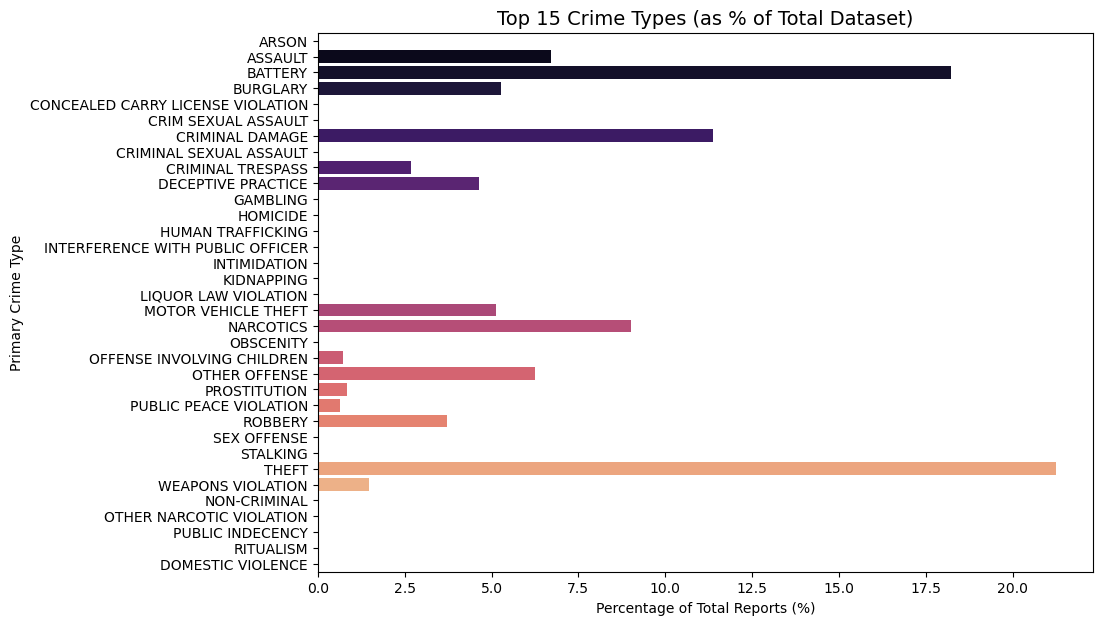

In [16]:
# Get all unique types
all_types = sorted(df['Primary Type'].unique())
print(f"Total unique crime categories: {len(all_types)}")
print("-" * 50)
print(", ".join(all_types))

# Calculate proportions for the Top 15
crime_counts = df['Primary Type'].value_counts(normalize=True).head(15) * 100

plt.figure(figsize=(10, 7))
sns.barplot(x=crime_counts.values, y=crime_counts.index, palette='magma')
plt.title('Top 15 Crime Types (as % of Total Dataset)', fontsize=14)
plt.xlabel('Percentage of Total Reports (%)')
plt.ylabel('Primary Crime Type')
plt.show()

### 7. Arrest Rates and Outcomes
A key metric for public safety is the "Arrest Rate." This section calculates the overall probability of an arrest and breaks it down by crime type to identify which incidents are most likely to remain "unsolved" in the data.

Global Average Arrest Rate: 25.15%


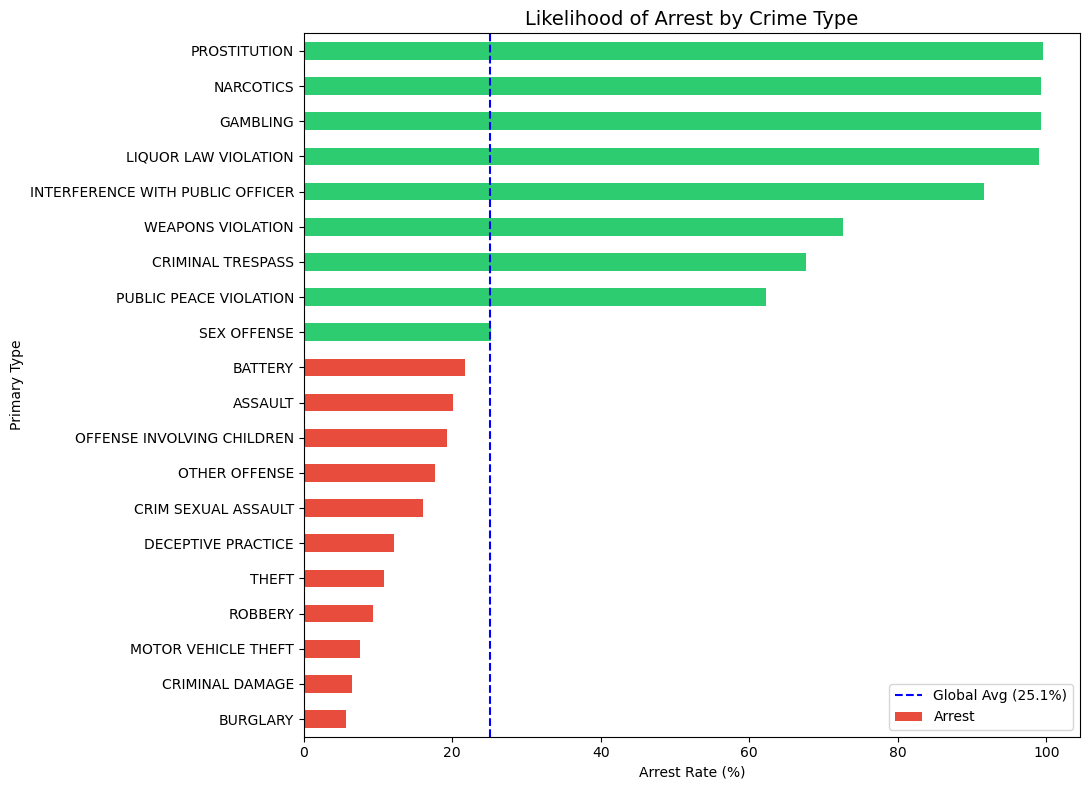

In [6]:
# Calculate overall arrest rate
overall_arrest_rate = df['Arrest'].mean() * 100
print(f"Global Average Arrest Rate: {overall_arrest_rate:.2f}%")

# Arrest rate by Crime Type (Top 20 most frequent)
top_20_types = df['Primary Type'].value_counts().nlargest(20).index
arrest_by_type = df[df['Primary Type'].isin(top_20_types)].groupby('Primary Type')['Arrest'].mean().sort_values() * 100

plt.figure(figsize=(11, 8))
colors = ['#e74c3c' if x < overall_arrest_rate else '#2ecc71' for x in arrest_by_type.values]
arrest_by_type.plot(kind='barh', color=colors)
plt.axvline(overall_arrest_rate, color='blue', linestyle='--', label=f'Global Avg ({overall_arrest_rate:.1f}%)')
plt.title('Likelihood of Arrest by Crime Type', fontsize=14)
plt.xlabel('Arrest Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()

### 8. Geographical Data Integrity
Since our final project relies heavily on mapping, we must assess the range of our coordinates and identify if there are "outlier" coordinates (like 0,0) that need to be filtered out before visualization.

In [8]:
# Check for missing coordinates
missing_geo = df['Latitude'].isnull().sum()
percent_missing = (missing_geo / len(df)) * 100

print(f"Missing Geographical Coordinates: {missing_geo:,}")
print(f"Percentage of data without location: {percent_missing:.2f}%")

Missing Geographical Coordinates: 94,671
Percentage of data without location: 1.11%


### Insight 1: Post-Pandemic Structural Shifts
We examine whether the location of crimes shifted permanently following 2020. With the rise of remote work, did 'Downtown/Street' crimes decrease in favor of 'Residential' area incidents?

In [9]:
# Compare Location Descriptions for 2019 vs 2023
df_shift = df[df['Year'].isin([2019, 2023])]
location_shift = df_shift.groupby(['Year', 'Location Description']).size().unstack(level=0)
location_shift['change_pct'] = ((location_shift[2023] - location_shift[2019]) / location_shift[2019]) * 100

# Show top 10 locations with biggest volume
print(location_shift.sort_values(by=2019, ascending=False).head(10))

Year                               2019     2023  change_pct
Location Description                                        
STREET                          56503.0  77679.0   37.477656
RESIDENCE                       43524.0  31882.0  -26.748461
APARTMENT                       35177.0  49455.0   40.589021
SIDEWALK                        20346.0  13052.0  -35.849798
OTHER                           10478.0      NaN         NaN
PARKING LOT/GARAGE(NON.RESID.)   7452.0      NaN         NaN
SMALL RETAIL STORE               7040.0   7266.0    3.210227
RESTAURANT                       6984.0   5401.0  -22.666094
ALLEY                            5119.0   6122.0   19.593671
RESIDENCE PORCH/HALLWAY          4884.0      NaN         NaN
